In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("willianoliveiragibin/healthcare-insurance")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 20.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/willianoliveiragibin/healthcare-insurance/versions/1


In [2]:
import os
import pandas as pd

# List files in the directory
files = os.listdir(path)
print(f"Files in directory: {files}")

# Assuming there is a CSV file, let's find it and load it
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"Displaying data from {csv_files[0]}:")
    display(df)
else:
    print("No CSV file found in the directory.")

Files in directory: ['insurance.csv']
Displaying data from insurance.csv:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
# Data Cleaning: Check for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any exist
if df.duplicated().any():
    df = df.drop_duplicates()
    print("Duplicates removed.")

# Display basic statistics
display(df.describe())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows: 1
Duplicates removed.


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# Preprocessing: Ensure data types are correct and prepare categorical encoding
# In this dataset, 'sex', 'smoker', and 'region' are categorical.

# Let's see the unique values to confirm categories
for col in ['sex', 'smoker', 'region']:
    print(f"Unique values in {col}: {df[col].unique()}")

# One-hot encoding for categorical variables is already handled in the training cell,
# but here we can define the processed dataframe for exploration.
df_processed = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
display(df_processed.head())

Unique values in sex: ['female' 'male']
Unique values in smoker: ['yes' 'no']
Unique values in region: ['southwest' 'southeast' 'northwest' 'northeast']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


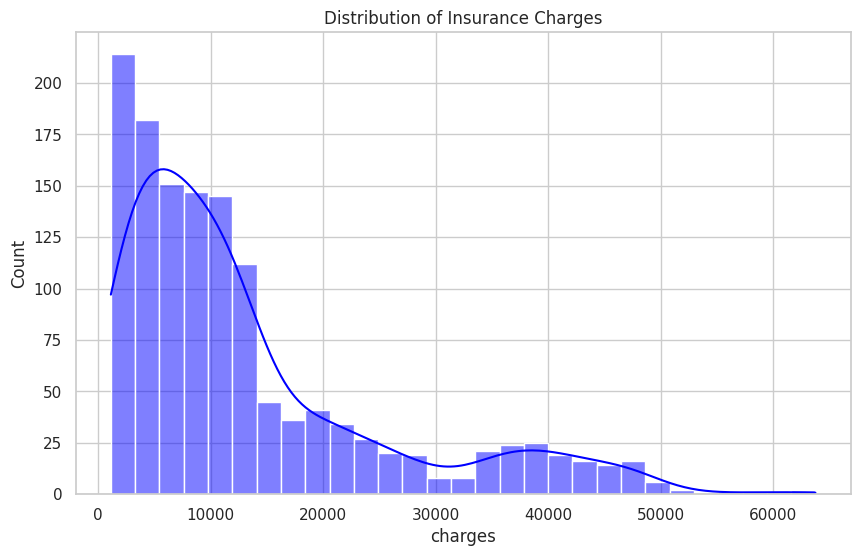

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style='whitegrid')

# 1. Distribution of Insurance Charges
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')
plt.show()

/tmp/ipykernel_666/210907367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


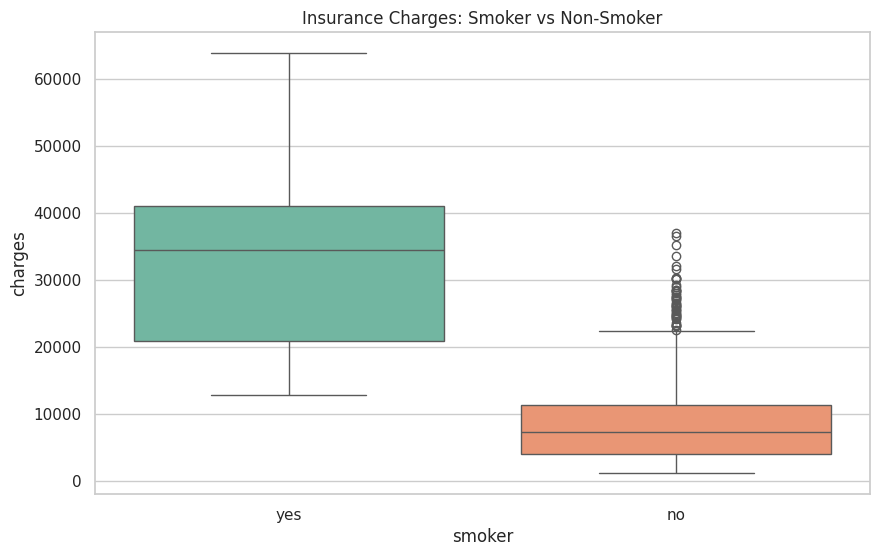

In [8]:
# 2. Charges by Smoking Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Insurance Charges: Smoker vs Non-Smoker')
plt.show()

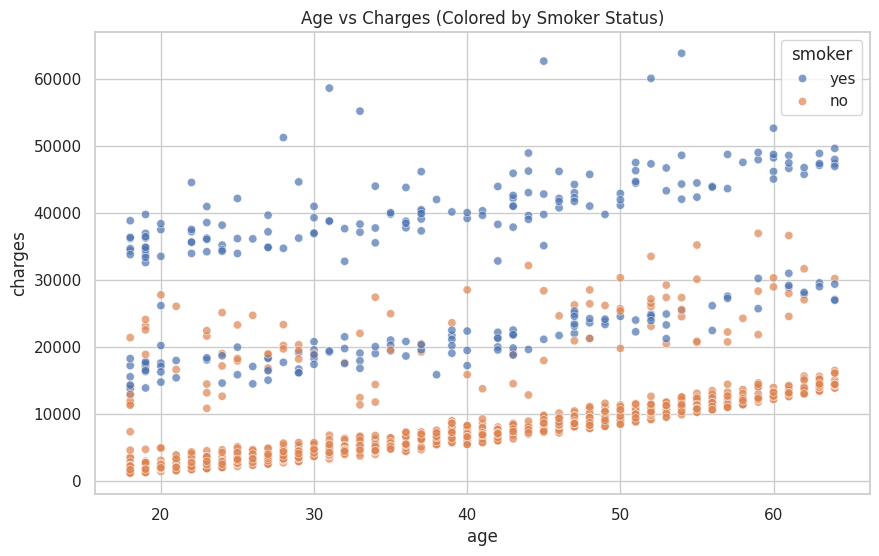

In [9]:
# 3. Age vs Charges colored by Smoking Status
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('Age vs Charges (Colored by Smoker Status)')
plt.show()

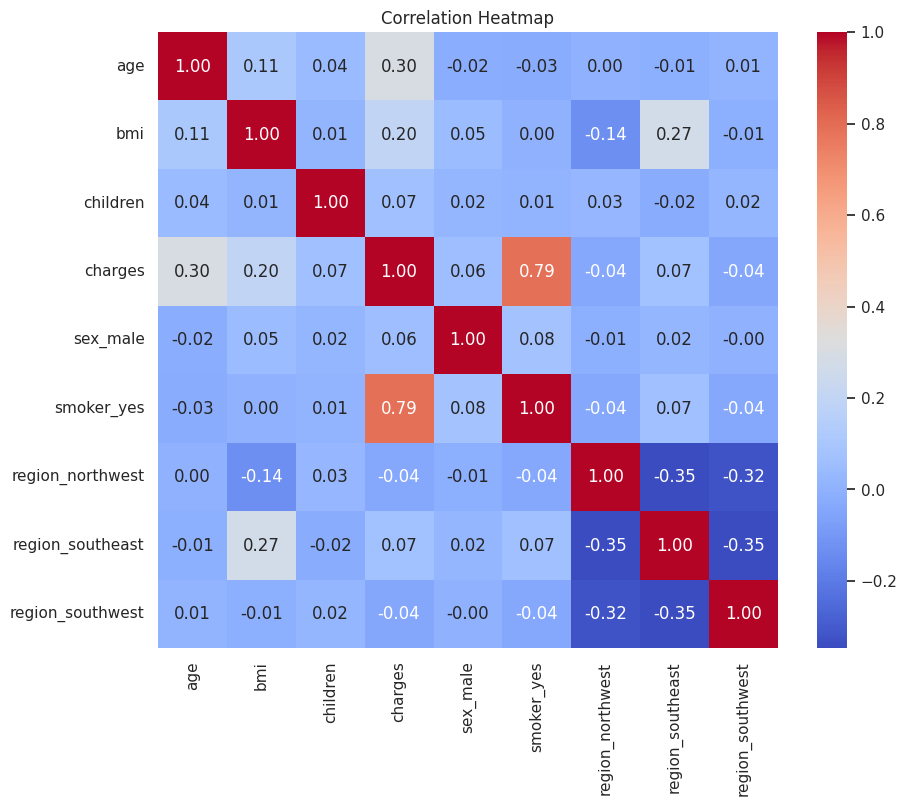

In [10]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_processed.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [3]:
!pip install scikit-learn==1.2.2 pandas==1.5.3 numpy==1.23.5 joblib==1.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 64.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 77.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


### Data Preprocessing and Model Training
We will encode categorical variables and split the data into training and testing sets before fitting a model.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Prepare features and target
# One-hot encode categorical variables: sex, smoker, region
X = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
y = X.pop('charges')

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Display feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
display(importances)

Mean Absolute Error: 2550.08
R2 Score: 0.87

Feature Importances:


,0
smoker_yes,0.608618
bmi,0.216506
age,0.134232
children,0.019413
sex_male,0.006379
region_northwest,0.005587
region_southeast,0.005314
region_southwest,0.003950


### Feature Engineering & Selection
We will create an interaction term between BMI and smoking status and then use Mutual Information to evaluate feature importance.

Mutual Information Scores (Higher is better):


,MI Scores
age,1.496824
bmi_smoker_interaction,0.512895
smoker_yes,0.369276
sex_male,0.176281
children,0.160483
bmi,0.074535
region_northwest,0.056791
region_southeast,0.035002
region_southwest,0.002465


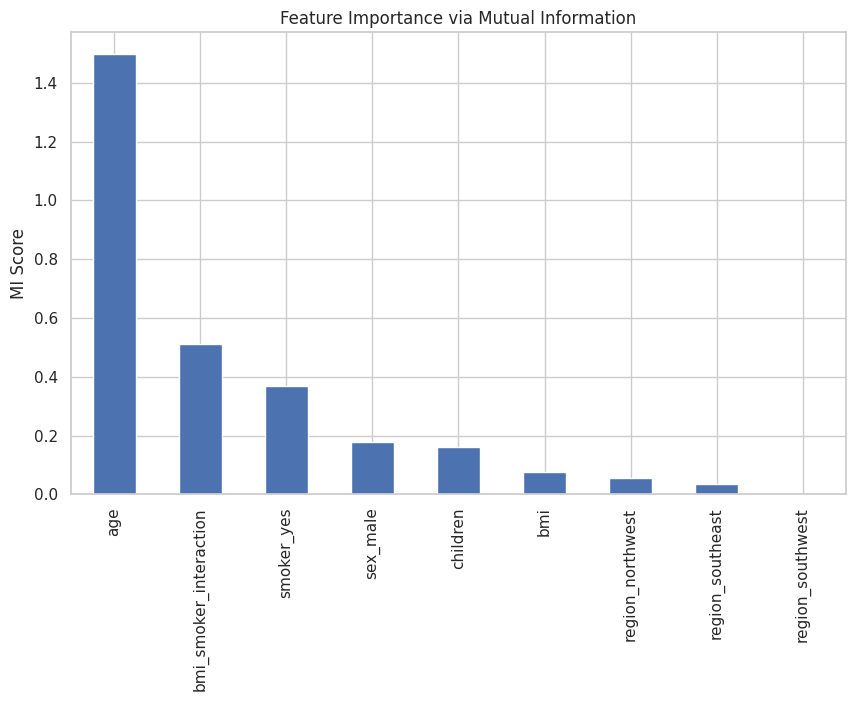

In [11]:
from sklearn.feature_selection import mutual_info_regression

# 1. Feature Engineering: BMI * Smoker Interaction
# High BMI is often much more expensive for smokers specifically.
df_processed['bmi_smoker_interaction'] = df_processed['bmi'] * df_processed['smoker_yes']

# 2. Feature Selection using Mutual Information
X_eng = df_processed.drop(columns=['charges'])
y_eng = df_processed['charges']

mi_scores = mutual_info_regression(X_eng, y_eng, random_state=42)
mi_results = pd.Series(mi_scores, name="MI Scores", index=X_eng.columns).sort_values(ascending=False)

print("Mutual Information Scores (Higher is better):")
display(mi_results)

# Visualize the MI Scores
plt.figure(figsize=(10, 6))
mi_results.plot.bar()
plt.title("Feature Importance via Mutual Information")
plt.ylabel("MI Score")
plt.show()

### Model Selection and Comparison
We will compare the performance of Linear Regression, Random Forest, and Gradient Boosting using 5-fold cross-validation to select the most reliable model.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Prepare features (using the engineered features including the interaction term)
X_final = df_processed.drop(columns=['charges'])
y_final = df_processed['charges']

results = {}

print("Model Comparison (R2 Score via 5-Fold CV):")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_final, y_final, cv=5, scoring='r2')
    results[name] = cv_scores.mean()
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Identify the best model
best_model_name = max(results, key=results.get)
print(f"\nBest performing model based on mean R2: {best_model_name}")

Model Comparison (R2 Score via 5-Fold CV):
Linear Regression: 0.8370 (+/- 0.0313)
Random Forest: 0.8371 (+/- 0.0296)
Gradient Boosting: 0.8545 (+/- 0.0323)

Best performing model based on mean R2: Gradient Boosting


### Final Model Training and Evaluation
Now that we've identified **Gradient Boosting** as the best model, we will perform a final fit on the training data and check the metrics on the hold-out test set.

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Split the engineered data
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Initialize and train the best model
final_model = GradientBoostingRegressor(random_state=42)
final_model.fit(X_train_final, y_train_final)

# Predict and Evaluate
y_pred_final = final_model.predict(X_test_final)

mae_final = mean_absolute_error(y_test_final, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
r2_final = r2_score(y_test_final, y_pred_final)

print(f"Final Gradient Boosting Performance:")
print(f"Mean Absolute Error: ${mae_final:.2f}")
print(f"Root Mean Squared Error: ${rmse_final:.2f}")
print(f"R2 Score: {r2_final:.4f}")

Final Gradient Boosting Performance:
Mean Absolute Error: $2445.27
Root Mean Squared Error: $4241.70
R2 Score: 0.9021


### Detailed Model Evaluation
We'll visualize the residuals to check if the model's errors are randomly distributed.

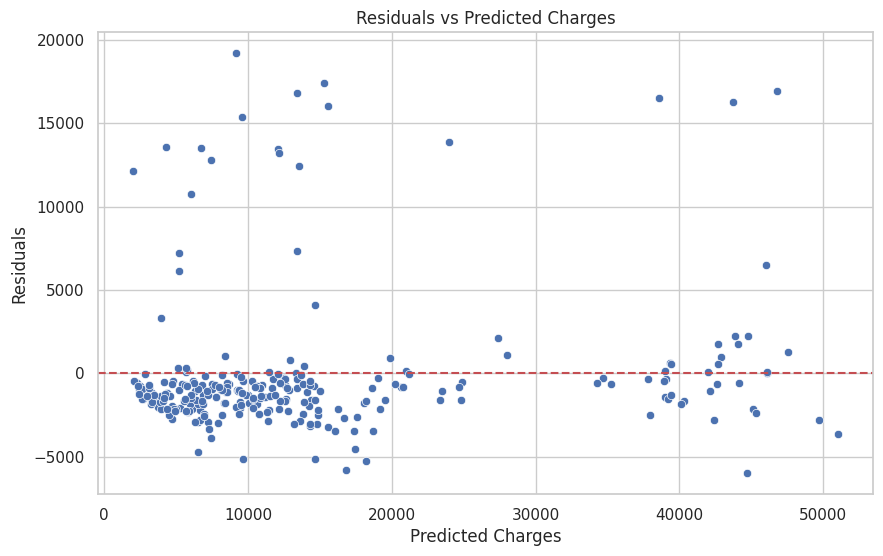

In [14]:
plt.figure(figsize=(10, 6))
residuals = y_test_final - y_pred_final
sns.scatterplot(x=y_pred_final, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Charges')
plt.show()

### Hyperparameter Tuning
We will use GridSearchCV to find the optimal parameters for the Gradient Boosting model.

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1)

grid_search.fit(X_train_final, y_train_final)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_final)
print(f"Tuned R2 Score: {r2_score(y_test_final, y_pred_tuned):.4f}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Validation Score: 0.8442
Tuned R2 Score: 0.9011


In [16]:
import joblib

# Save the final model to a file
joblib.dump(final_model, 'model.pkl')

print("Model saved successfully as 'model.pkl'")

Model saved successfully as 'model.pkl'
